In [1]:
import string
import textwrap

import dask.diagnostics
import faceted
import numpy as np
import obstore
import pandas as pd
import xarray as xr
import xhistogram.xarray as xh
import zarr

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from upath import UPath

import plotting

In [2]:
ROOT = UPath("gs://vcm-ml-experiments/spencerc/2026-04-25-ace-equilibrium-climate-inference")

SECONDS_PER_DAY = 86400

In [3]:
CLIMATES = ["3xCO2"]
INITIAL_CONDITIONS = [f"ic{i}" for i in range(1, 6)]
MODELS = {
    "SHiELD-SOM": "data-only-evaluator",
    "ACE2-SOM": "published-baseline-rs3",
    "full energy-conserving rs0": "full-energy-conserving-rs0",
}

In [4]:
def infer_bucket(path: UPath):
    return path.anchor.replace("/", "")


def open_zarr_with_obstore(path: UPath):
    bucket = infer_bucket(path)
    prefix = path.relative_to(bucket).as_posix()
    print(prefix)
    gcs_store = obstore.store.GCSStore(bucket, prefix=prefix)
    zarr_store = zarr.storage.ObjectStore(gcs_store)
    ds = xr.open_zarr(zarr_store, chunks={"time": 520}, decode_timedelta=False)
    return ds.assign(PRATEsfc=(ds.PRATEsfc * SECONDS_PER_DAY).assign_attrs(units="mm/day"))


def open_case(model, climate, initial_condition):
    path = ROOT / f"{MODELS[model]}-{climate}-{initial_condition}" / "main" / "daily.zarr"
    print(path)
    return open_zarr_with_obstore(path)


def open_daily_precipitation():
    import logging
    logging.basicConfig(level=logging.INFO)
    datasets = []
    total_iterations = len(MODELS) * len(INITIAL_CONDITIONS) * len(CLIMATES)
    current_iteration = 0
    for model in MODELS:
        for initial_condition in INITIAL_CONDITIONS:
            for climate in CLIMATES:
                current_iteration += 1
                logging.info(f"Processing {current_iteration}/{total_iterations}: model={model}, initial_condition={initial_condition}, climate={climate}")
                ds = open_case(model, climate, initial_condition)
                ds = ds.expand_dims({"model": [model], "climate": [climate], "initial_condition": [initial_condition]})
                datasets.append(ds)
    return xr.combine_by_coords(datasets, combine_attrs="drop_conflicts")


def open_power_spectrum(model, climate, initial_condition):
    path = ROOT / f"{MODELS[model]}-{climate}-{initial_condition}" / "main" / "power_spectrum_diagnostics.nc"
    return xr.open_dataset(str(path), engine="h5netcdf").load()


def open_power_spectra():
    import logging
    logging.basicConfig(level=logging.INFO)
    datasets = []
    total_iterations = len(MODELS) * len(INITIAL_CONDITIONS) * len(CLIMATES)
    current_iteration = 0
    for model in MODELS:
        for initial_condition in INITIAL_CONDITIONS:
            for climate in CLIMATES:
                current_iteration += 1
                logging.info(f"Processing {current_iteration}/{total_iterations}: model={model}, initial_condition={initial_condition}, climate={climate}")
                ds = open_power_spectrum(model, climate, initial_condition)
                ds = ds.expand_dims({"model": [model], "climate": [climate], "initial_condition": [initial_condition]})
                datasets.append(ds)
    return xr.combine_by_coords(datasets, combine_attrs="drop_conflicts")


In [5]:
daily_precipitation = open_daily_precipitation()
power_spectra = open_power_spectra()

INFO:root:Processing 1/15: model=SHiELD-SOM, initial_condition=ic1, climate=3xCO2


gs://vcm-ml-experiments/spencerc/2026-04-25-ace-equilibrium-climate-inference/data-only-evaluator-3xCO2-ic1/main/daily.zarr
spencerc/2026-04-25-ace-equilibrium-climate-inference/data-only-evaluator-3xCO2-ic1/main/daily.zarr


/tmp/ipykernel_21331/1345593621.py:11: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 520. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(zarr_store, chunks={"time": 520}, decode_timedelta=False)
INFO:root:Processing 2/15: model=SHiELD-SOM, initial_condition=ic2, climate=3xCO2


gs://vcm-ml-experiments/spencerc/2026-04-25-ace-equilibrium-climate-inference/data-only-evaluator-3xCO2-ic2/main/daily.zarr
spencerc/2026-04-25-ace-equilibrium-climate-inference/data-only-evaluator-3xCO2-ic2/main/daily.zarr


/tmp/ipykernel_21331/1345593621.py:11: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 520. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(zarr_store, chunks={"time": 520}, decode_timedelta=False)
INFO:root:Processing 3/15: model=SHiELD-SOM, initial_condition=ic3, climate=3xCO2


...

/tmp/ipykernel_21331/1345593621.py:11: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 520. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(zarr_store, chunks={"time": 520}, decode_timedelta=False)
INFO:root:Processing 14/15: model=full energy-conserving rs0, initial_condition=ic4, climate=3xCO2


gs://vcm-ml-experiments/spencerc/2026-04-25-ace-equilibrium-climate-inference/full-energy-conserving-rs0-3xCO2-ic4/main/daily.zarr
spencerc/2026-04-25-ace-equilibrium-climate-inference/full-energy-conserving-rs0-3xCO2-ic4/main/daily.zarr


/tmp/ipykernel_21331/1345593621.py:11: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 520. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(zarr_store, chunks={"time": 520}, decode_timedelta=False)
INFO:root:Processing 15/15: model=full energy-conserving rs0, initial_condition=ic5, climate=3xCO2


gs://vcm-ml-experiments/spencerc/2026-04-25-ace-equilibrium-climate-inference/full-energy-conserving-rs0-3xCO2-ic5/main/daily.zarr
spencerc/2026-04-25-ace-equilibrium-climate-inference/full-energy-conserving-rs0-3xCO2-ic5/main/daily.zarr


/tmp/ipykernel_21331/1345593621.py:11: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 520. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(zarr_store, chunks={"time": 520}, decode_timedelta=False)
INFO:root:Processing 1/15: model=SHiELD-SOM, initial_condition=ic1, climate=3xCO2
INFO:gcsfs:gcsfs experimental features enabled via GCSFS_EXPERIMENTAL_ZB_HNS_SUPPORT.
INFO:fsspec.caching:BlockCache fetching block 0
INFO:root:Processing 2/15: model=SHiELD-SOM, initial_condition=ic2, climate=3xCO2
INFO:fsspec.caching:BlockCache fetching block 0
INFO:root:Processing 3/15: model=SHiELD-SOM, initial_condition=ic3, climate=3xCO2
INFO:fsspec.caching:BlockCache fetching block 0
INFO:root:Processing 4/15: model=SHiELD-SOM, initial_condition=ic4, climate=3xCO2
INFO:fsspec.caching:BlockCache fetching block 0
INFO:root:Processing 5/15: model=SHiELD-SOM, initial_condition=ic5, climate=3xCO2
INFO:fsspec.

In [6]:
bins = np.linspace(0, 1000, 101)
histogram = xh.histogram(
    daily_precipitation.PRATEsfc, 
    bins=bins, 
    dim=["lat", "lon", "time", "sample", "initial_condition"], 
    block_size=None
)
with dask.diagnostics.ProgressBar():
    histogram = histogram.compute()

bin_width, *_ = np.diff(bins)
density = histogram / (histogram.sum("PRATEsfc_bin") * bin_width)

[                                        ] | 0% Completed | 278.55 us

[########################################] | 100% Completed | 108.21 s


In [7]:
COLORS = {
    "SHiELD-SOM": "k",
    "ACE2-SOM": "C3",
    "full energy-conserving rs0": "C4",
}
LABELS = {
    "SHiELD-SOM": "SHiELD",
    "ACE2-SOM": "ACE2-SOM",
    "full energy-conserving rs0": "ACE2S-SHiELD+",
}

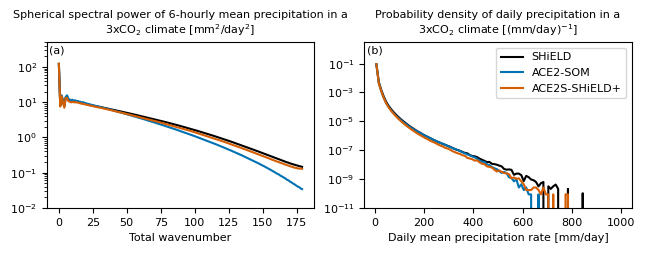

In [8]:
plotting.configure_style()

fig, (ax1, ax2) = faceted.faceted(1, 2, width=6.5, aspect=0.618, internal_pad=0.5, sharex=False, sharey=False, left_pad=0.4, bottom_pad=0.4, top_pad=0.5)

for model, color in COLORS.items():
    (SECONDS_PER_DAY ** 2 * power_spectra.PRATEsfc).sel(model=model, source="prediction", climate="3xCO2").mean("initial_condition").plot(yscale="log", ax=ax1, color=color)
    density.sel(model=model, climate="3xCO2").plot(yscale="log", ax=ax2, color=color, label=LABELS[model])

ax1.set_xlabel("Total wavenumber")
ax1.set_title(textwrap.fill("Spherical spectral power of 6-hourly mean precipitation in a 3xCO$_2$ climate [mm$^2$/day$^2$]", width=60))

ax2.set_xlabel("Daily mean precipitation rate [mm/day]")
ax2.set_title(textwrap.fill("Probability density of daily precipitation in a 3xCO$_2$ climate [(mm/day)$^{-1}$]", width=50))

for ax in (ax1, ax2):
    ax.set_ylabel("")

ax2.legend()

ax1.set_ylim(1e-2, 5e2)
ax2.set_ylim(1e-11, 3)

for ax, label in zip((ax1, ax2), string.ascii_lowercase):
    ax.annotate(
        f"({label})",
        xy=(0, 1),
        xytext=(2, -2),
        va="top",
        xycoords="axes fraction",
        textcoords="offset points",
    )

fig.patch.set_alpha(0.0)
fig.savefig("figure-S01.png", dpi=300)
fig.savefig("figure-S01.pdf")